# 08 · Topic & Abstract Analysis

**Week 8 Goal:** Extract research topics from grant abstracts and characterize topic trends across colleges and agencies.

Sections:
1. Setup & data load
2. Abstract corpus quality check
3. Text preprocessing & TF-IDF
4. LDA topic modeling (15–25 topics)
5. Topic prevalence over time
6. Topics by college
7. Topic ↔ agency affinity
8. Validation against `ri_matches_grants_2026` research-interest tags
9. Export topic table

> **Note:** Install missing packages if needed:
> ```
> pip install scikit-learn gensim pyLDAvis nltk wordcloud
> ```

In [23]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

try:
    import nltk
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words('english'))
except Exception:
    STOP_WORDS = set()

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
OUTPUTS_DIR   = REPO_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
print('Repo root:', REPO_ROOT)

Repo root: /Users/uttkarshnarayan/projects/northeastern_visualization


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


In [24]:
faculty       = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants        = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
grant_faculty = pd.read_parquet(PROCESSED_DIR / 'grant_faculty.parquet')
grant_text    = pd.read_parquet(PROCESSED_DIR / 'grant_text.parquet')

print(f'grant_text shape: {grant_text.shape}')
print(f'grant_text columns: {list(grant_text.columns)}')
print(grant_text.head(3))

grant_text shape: (8075, 5)
grant_text columns: ['id', 'title', 'abstract', 'start date', 'sourceactivityid']
      id                                              title  \
0  91740             Some determinants of speech perception   
1  91741  TWC: Small: Collaborative: An Iterative Approa...   
2  91708  CHS: Small: Collaborative Research: Teleoperat...   

                                            abstract start date  \
0                                                    2005-07-01   
1  Secure multi-party computation (MPC) allows se... 2016-09-15   
2  Magnetic resonance imaging (MRI) is a widely u... 2016-08-01   

  sourceactivityid  
0           131902  
1          1169275  
2          1120636  


## 1 · Abstract Corpus Quality Check

In [25]:
# Identify abstract text column
abs_col = 'abstract' if 'abstract' in grant_text.columns else grant_text.columns[0]
id_col  = 'sourceactivityid' if 'sourceactivityid' in grant_text.columns else 'id'

gt = grant_text.copy()
gt['has_abstract'] = gt[abs_col].notna() & (gt[abs_col].str.strip() != '')
gt['abstract_len'] = gt[abs_col].fillna('').str.split().str.len()

print(f"Records in grant_text: {len(gt):,}")
print(f"With non-empty abstract: {gt['has_abstract'].sum():,} ({gt['has_abstract'].mean()*100:.1f}%)")
print(f"Abstract word count: median={gt.loc[gt['has_abstract'], 'abstract_len'].median():.0f}, "
      f"mean={gt.loc[gt['has_abstract'], 'abstract_len'].mean():.0f}")

# Match back to grants
n_grants_total = grants['grantid'].nunique()
grants_with_abs = grants['grantid'].isin(
    gt[gt['has_abstract']][id_col].unique()
).sum()
print(f"\nGrants with ≥1 non-empty abstract: {grants_with_abs:,} of {n_grants_total:,} "
      f"({grants_with_abs/n_grants_total*100:.1f}%)")

Records in grant_text: 8,075
With non-empty abstract: 2,873 (35.6%)
Abstract word count: median=360, mean=360

Grants with ≥1 non-empty abstract: 1,928 of 2,676 (72.0%)


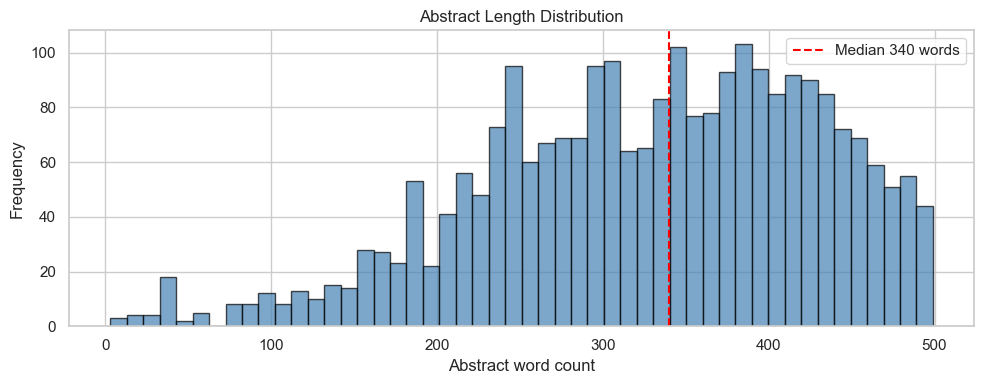

In [26]:
# Word count distribution
fig, ax = plt.subplots(figsize=(10, 4))
wc = gt.loc[gt['has_abstract'] & (gt['abstract_len'] < 500), 'abstract_len']
ax.hist(wc, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(wc.median(), color='red', linestyle='--', label=f'Median {wc.median():.0f} words')
ax.set_xlabel('Abstract word count')
ax.set_ylabel('Frequency')
ax.set_title('Abstract Length Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_abstract_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Text Preprocessing

In [27]:
# Custom stop words to remove non-informative research boilerplate
DOMAIN_STOP = {
    'research', 'study', 'project', 'work', 'proposal', 'provide', 'use', 'used',
    'using', 'develop', 'development', 'new', 'approach', 'result', 'results',
    'support', 'university', 'northeastern', 'national', 'science', 'foundation',
    'program', 'grant', 'award', 'funding', 'objective', 'goal', 'focus',
    'include', 'including', 'based', 'also', 'well', 'will', 'may', 'one', 'two',
    'three', 'first', 'second', 'proposed', 'propose', 'aim', 'aims',
}
ALL_STOP = STOP_WORDS | DOMAIN_STOP

def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, strip short tokens."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [w for w in text.split()
              if len(w) > 2 and w not in ALL_STOP]
    return ' '.join(tokens)

# Work with deduplicated abstracts (one per sourceactivityid)
corpus_df = (gt[gt['has_abstract']]
             .drop_duplicates(subset=[id_col])
             .copy())
corpus_df['clean_abstract'] = corpus_df[abs_col].apply(clean_text)

# Remove very short documents after cleaning
corpus_df = corpus_df[corpus_df['clean_abstract'].str.split().str.len() >= 20]
print(f'Documents for modeling: {len(corpus_df):,}')

Documents for modeling: 2,305


## 3 · TF-IDF Top Terms

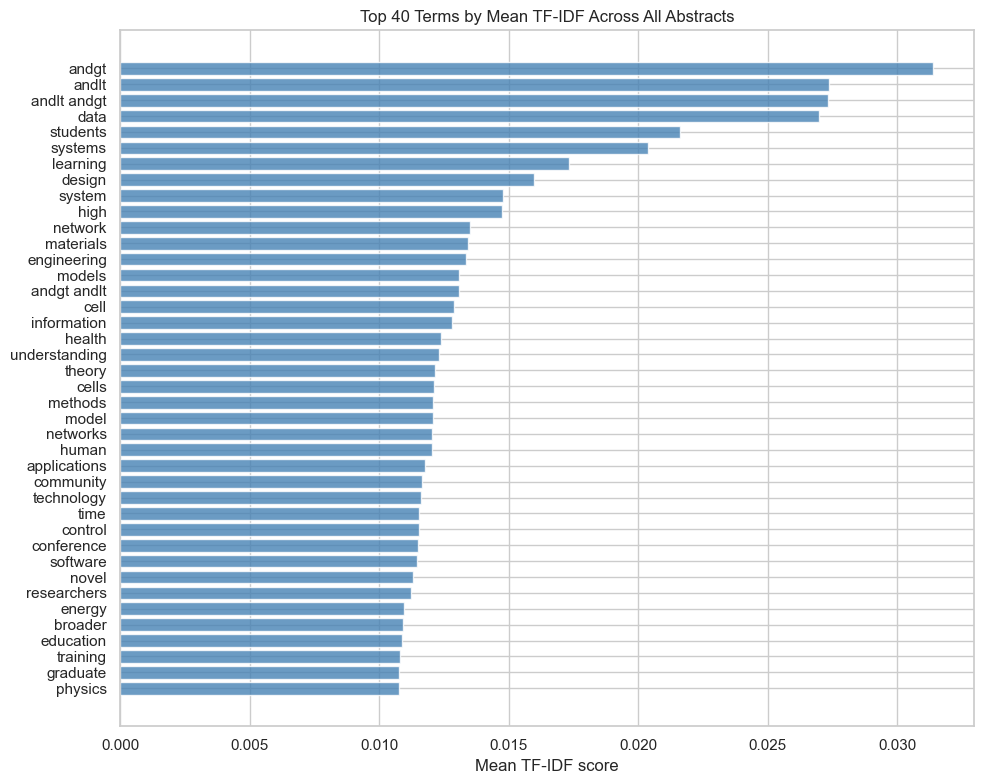

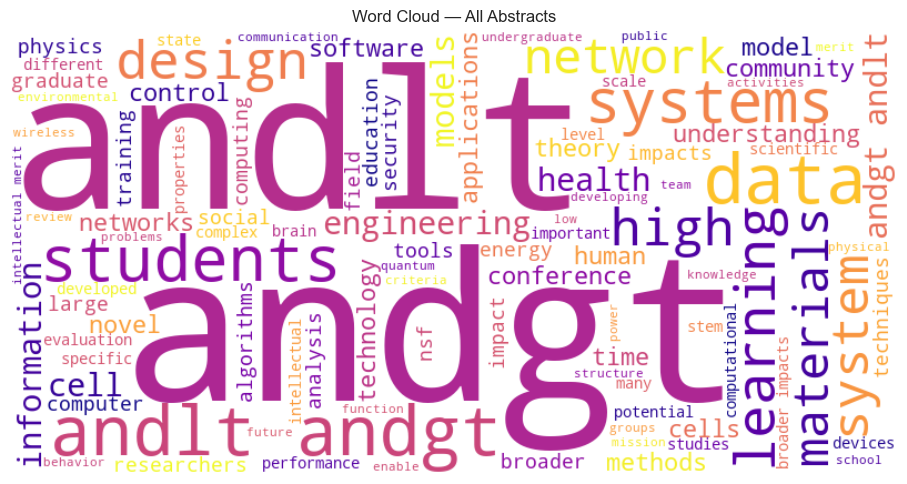

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words=list(ALL_STOP),
)
tfidf_matrix = tfidf.fit_transform(corpus_df['clean_abstract'])
feature_names = tfidf.get_feature_names_out()

# Global top TF-IDF terms
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_terms_idx = mean_tfidf.argsort()[::-1][:40]
top_terms = pd.DataFrame({
    'term': feature_names[top_terms_idx],
    'mean_tfidf': mean_tfidf[top_terms_idx],
})

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_terms['term'][::-1], top_terms['mean_tfidf'][::-1],
        color='steelblue', alpha=0.8)
ax.set_xlabel('Mean TF-IDF score')
ax.set_title('Top 40 Terms by Mean TF-IDF Across All Abstracts')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_top_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

# Word cloud
if HAS_WORDCLOUD:
    freq_dict = dict(zip(feature_names, mean_tfidf))
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='plasma').generate_from_frequencies(freq_dict)
    fig_wc, ax_wc = plt.subplots(figsize=(12, 5))
    ax_wc.imshow(wc, interpolation='bilinear')
    ax_wc.axis('off')
    ax_wc.set_title('Word Cloud — All Abstracts')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'w8_wordcloud_all.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4 · LDA Topic Modeling

In [29]:
# Count vectorizer for LDA (LDA needs raw counts, not TF-IDF)
count_vec = CountVectorizer(
    max_features=4000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words=list(ALL_STOP),
)
count_matrix = count_vec.fit_transform(corpus_df['clean_abstract'])
count_features = count_vec.get_feature_names_out()

N_TOPICS = 20
print(f'Fitting LDA with {N_TOPICS} topics on {count_matrix.shape[0]:,} documents…')

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1,
)
doc_topic_matrix = lda.fit_transform(count_matrix)
print(f'LDA perplexity (lower = better fit): {lda.perplexity(count_matrix):.1f}')

Fitting LDA with 20 topics on 2,305 documents…
LDA perplexity (lower = better fit): 1648.3


In [30]:
# Top terms per topic
N_TOP_WORDS = 15
topic_rows = []
for i, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[::-1][:N_TOP_WORDS]
    top_words = [count_features[j] for j in top_idx]
    topic_rows.append({'topic_id': i, 'top_terms': ', '.join(top_words[:10]),
                       'top_terms_full': top_words})

topic_df = pd.DataFrame(topic_rows)

# Display formatted topic table
print(f'\n{"=" * 80}')
print(f'LDA Topics ({N_TOPICS} topics, top 10 terms each)')
print(f'{"=" * 80}')
for _, row in topic_df.iterrows():
    print(f'Topic {row["topic_id"]:02d}: {row["top_terms"]}')


LDA Topics (20 topics, top 10 terms each)
Topic 00: theory, quantum, geometry, algebras, algebraic, spaces, physics, objects, mathematical, representation
Topic 01: researchers, conference, students, community, workshop, scientists, scientific, together, field, international
Topic 02: materials, polymer, via, energy, processing, composites, high, composite, low, heterogeneous
Topic 03: students, education, engineering, stem, school, graduate, undergraduate, faculty, programs, underrepresented
Topic 04: health, social, risk, cognitive, people, behavioral, learning, children, data, intervention
Topic 05: data, tools, methods, large, algorithms, analysis, computational, models, techniques, information
Topic 06: security, software, privacy, systems, internet, programming, languages, design, attacks, secure
Topic 07: health, environmental, smart, cyber, cybersecurity, wind, policy, energy, trafficking, exposure
Topic 08: imaging, spin, dna, magnetic, proteins, optical, resolution, visual, 

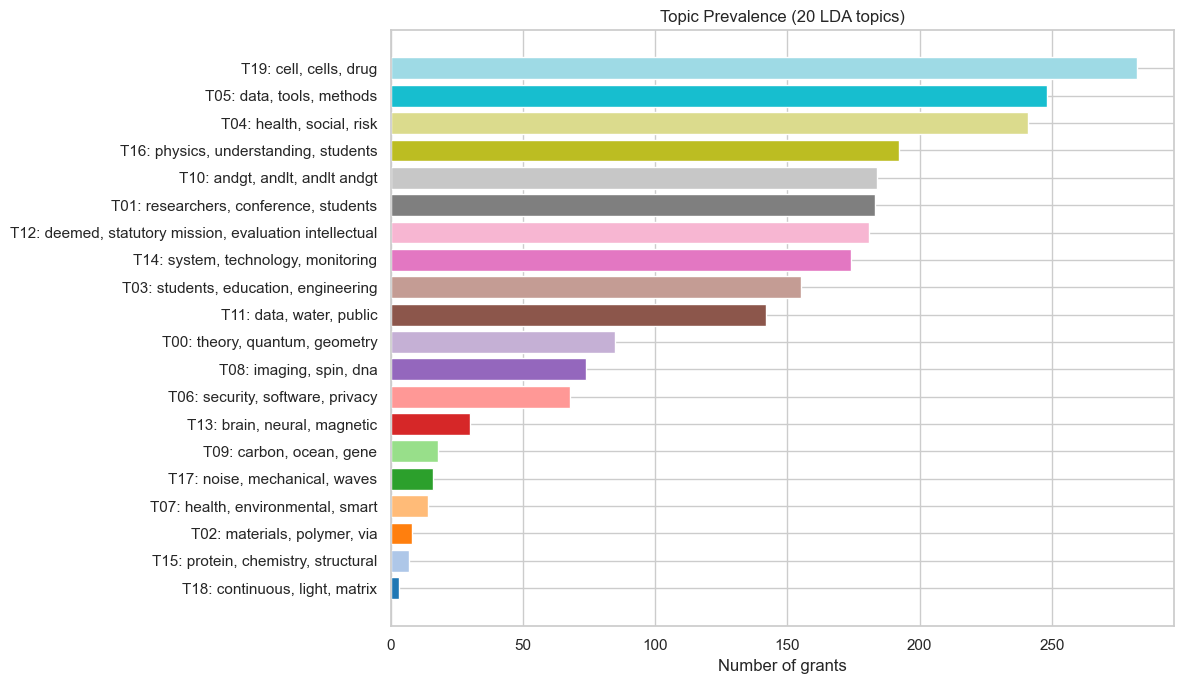

,topic_id,n_docs,top_terms,pct
0,19,282,"cell, cells, drug, cancer, specific, novel, di...",12.234273
1,5,248,"data, tools, methods, large, algorithms, analy...",10.759219
2,4,241,"health, social, risk, cognitive, people, behav...",10.455531
3,16,192,"physics, understanding, students, biological, ...",8.329718
4,10,184,"andgt, andlt, andlt andgt, andgt andlt, learni...",7.982646
5,1,183,"researchers, conference, students, community, ...",7.939262
6,12,181,"deemed, statutory mission, evaluation intellec...",7.852495
7,14,174,"system, technology, monitoring, design, detect...",7.548807
8,3,155,"students, education, engineering, stem, school...",6.724512
9,11,142,"data, water, public, impacts, climate, human, ...",6.160521


In [31]:
# Assign dominant topic to each document
corpus_df = corpus_df.copy()
corpus_df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
corpus_df['topic_confidence'] = doc_topic_matrix.max(axis=1)

# Topic prevalence
prevalence = (corpus_df['dominant_topic']
              .value_counts()
              .reset_index()
              .rename(columns={'dominant_topic': 'topic_id', 'count': 'n_docs'}))

# Handle older pandas naming
if 'index' in prevalence.columns:
    prevalence.columns = ['topic_id', 'n_docs']

prevalence = prevalence.merge(topic_df[['topic_id', 'top_terms']], on='topic_id')
prevalence['pct'] = prevalence['n_docs'] / prevalence['n_docs'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 7))
short_label = lambda row: f"T{row['topic_id']:02d}: {', '.join(row['top_terms'].split(', ')[:3])}"
labels = [short_label(r) for _, r in prevalence.sort_values('n_docs').iterrows()]
ax.barh(labels, prevalence.sort_values('n_docs')['n_docs'],
        color=plt.get_cmap('tab20')(np.linspace(0, 1, len(prevalence))))
ax.set_xlabel('Number of grants')
ax.set_title(f'Topic Prevalence ({N_TOPICS} LDA topics)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_topic_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

display(prevalence)

## 5 · Topic Prevalence Over Time

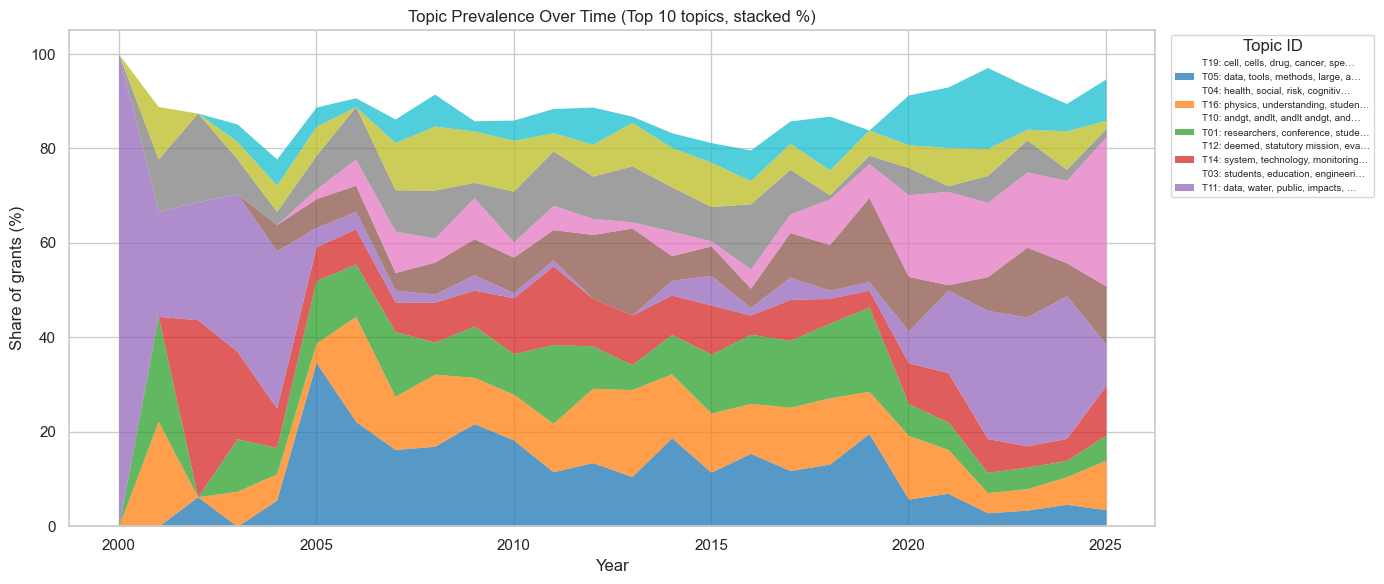

In [32]:
# Merge dominant topic back to grants table to get year
corpus_yr = corpus_df.merge(
    grants[['grantid', 'startdateyear']],
    left_on=id_col, right_on='grantid', how='left'
).dropna(subset=['startdateyear'])
corpus_yr = corpus_yr[(corpus_yr['startdateyear'] >= 2000) &
                       (corpus_yr['startdateyear'] <= 2025)].copy()

topic_yr = (corpus_yr
            .groupby(['startdateyear', 'dominant_topic'])
            .size()
            .unstack(fill_value=0)
            .apply(lambda x: x / x.sum() * 100, axis=1))  # normalize to %

# Stacked area chart — top 10 topics only
top10_topics = prevalence.sort_values('n_docs', ascending=False).head(10)['topic_id'].tolist()
topic_yr_top = topic_yr[[c for c in top10_topics if c in topic_yr.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
topic_yr_top.plot(kind='area', stacked=True, ax=ax,
                  colormap='tab10', alpha=0.75, linewidth=0)
ax.set_xlabel('Year')
ax.set_ylabel('Share of grants (%)')
ax.set_title('Topic Prevalence Over Time (Top 10 topics, stacked %)')
ax.legend(title='Topic ID',
          labels=[f'T{t:02d}: {topic_df.loc[t, "top_terms"][:30]}…' for t in topic_yr_top.columns],
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_topic_prevalence_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Topics by College

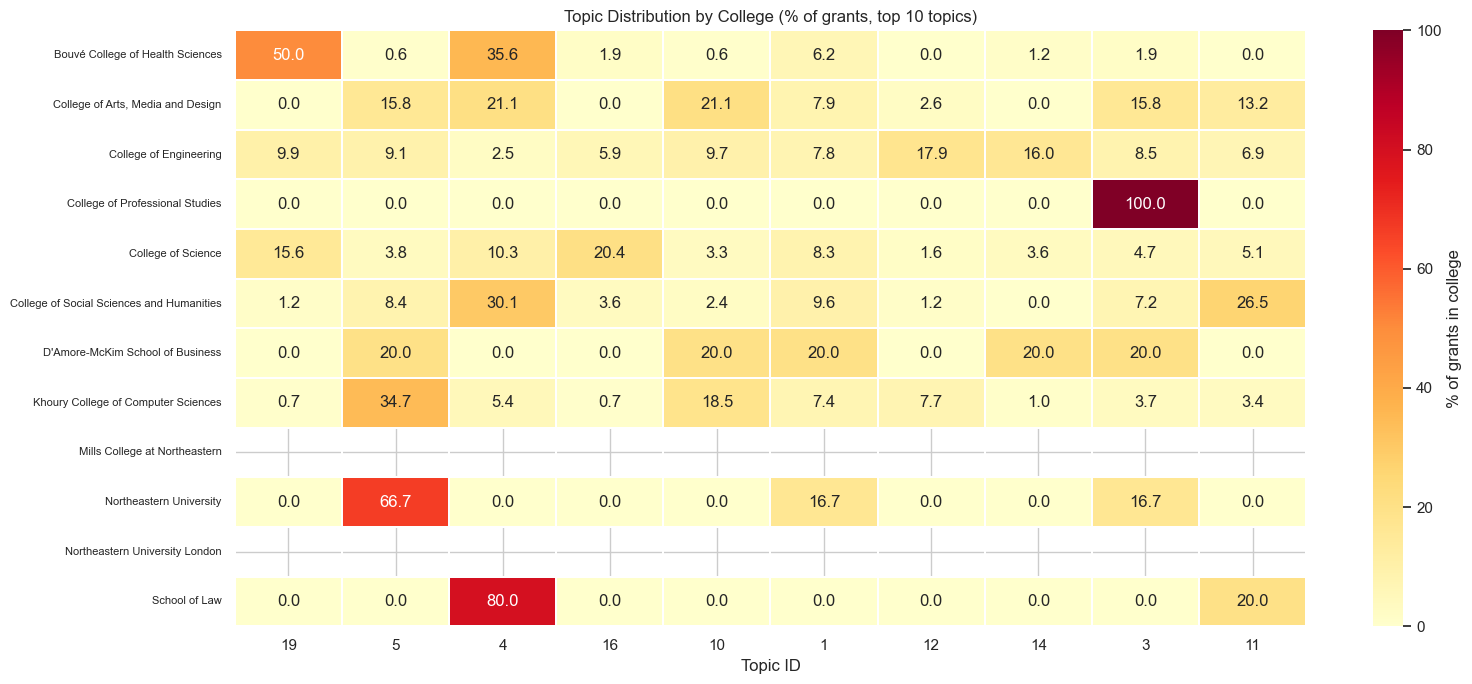

In [34]:
# Map grants to college via grant_faculty → faculty
grant_to_college = (grant_faculty
                    .merge(faculty[['employee id', 'superior_academic_unit']],
                           left_on='clientfacultyid', right_on='employee id', how='left')
                    .dropna(subset=['superior_academic_unit'])
                    .groupby('grantid')['superior_academic_unit']
                    .first())

corpus_college = corpus_yr.copy()
corpus_college['college'] = corpus_college['grantid'].map(grant_to_college)
corpus_college = corpus_college.dropna(subset=['college'])

topic_college = (corpus_college
                 .groupby(['college', 'dominant_topic'])
                 .size()
                 .unstack(fill_value=0))
# Normalize to row %
topic_college_pct = topic_college.div(topic_college.sum(axis=1), axis=0) * 100

# Heatmap: college × topic
fig, ax = plt.subplots(figsize=(16, 7))
cols_present = [c for c in top10_topics if c in topic_college_pct.columns]
sns.heatmap(topic_college_pct[cols_present], annot=True, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': '% of grants in college'})
ax.set_title('Topic Distribution by College (% of grants, top 10 topics)')
ax.set_xlabel('Topic ID')
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_topic_by_college.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Topic ↔ Agency Affinity

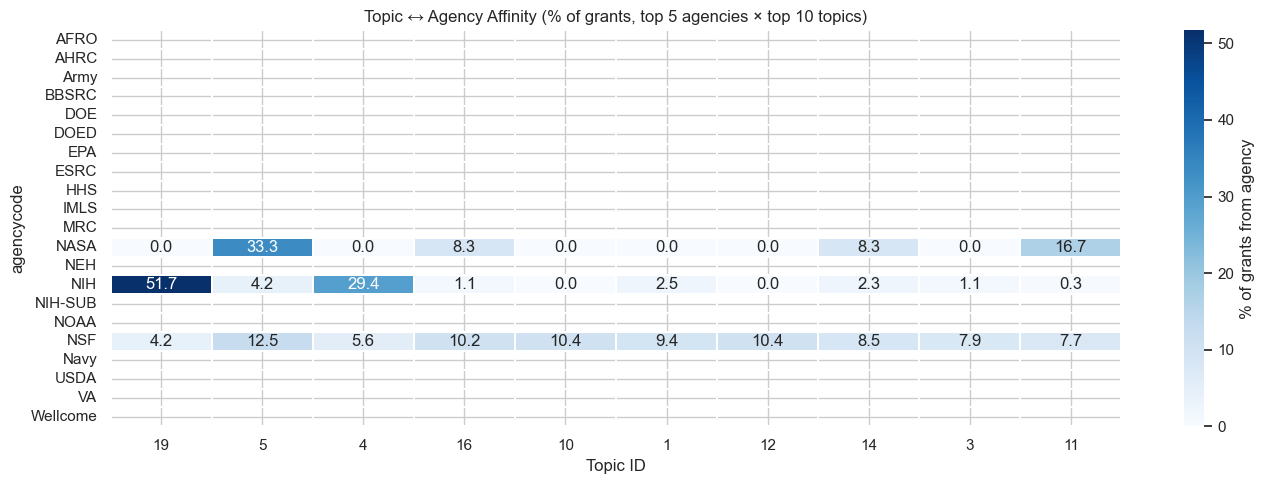

In [35]:
a_col = 'agencycode' if 'agencycode' in grants.columns else 'agencyname'
top5_agencies = grants[a_col].value_counts().head(5).index.tolist()

corpus_agency = corpus_yr.merge(
    grants[['grantid', a_col]], on='grantid', how='left'
).dropna(subset=[a_col])
corpus_agency = corpus_agency[corpus_agency[a_col].isin(top5_agencies)]

topic_agency = (corpus_agency
                .groupby([a_col, 'dominant_topic'])
                .size()
                .unstack(fill_value=0)
                .div(corpus_agency.groupby(a_col).size(), axis=0) * 100)

fig, ax = plt.subplots(figsize=(14, 5))
cols_present = [c for c in top10_topics if c in topic_agency.columns]
sns.heatmap(topic_agency[cols_present], annot=True, fmt='.1f',
            cmap='Blues', ax=ax, linewidths=0.3,
            cbar_kws={'label': '% of grants from agency'})
ax.set_title('Topic ↔ Agency Affinity (% of grants, top 5 agencies × top 10 topics)')
ax.set_xlabel('Topic ID')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w8_topic_agency_affinity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Export Topic Table

In [36]:
# Build full topic summary table
topic_summary = topic_df.merge(prevalence[['topic_id', 'n_docs', 'pct']], on='topic_id')
topic_summary = topic_summary[['topic_id', 'n_docs', 'pct', 'top_terms']].sort_values('n_docs', ascending=False)

topic_summary.to_csv(OUTPUTS_DIR / 'topic_table.csv', index=False)

# Save document-topic assignments for downstream use (dashboard)
doc_topic_df = corpus_df[[id_col, 'dominant_topic', 'topic_confidence']].copy()
doc_topic_df.to_parquet(PROCESSED_DIR / 'grant_topics.parquet', index=False)

print('Saved topic_table.csv and data/processed/grant_topics.parquet')
print(f'\nTopic summary ({N_TOPICS} topics):')
display(topic_summary)

Saved topic_table.csv and data/processed/grant_topics.parquet

Topic summary (20 topics):


,topic_id,n_docs,pct,top_terms
19,19,282,12.234273,"cell, cells, drug, cancer, specific, novel, di..."
5,5,248,10.759219,"data, tools, methods, large, algorithms, analy..."
4,4,241,10.455531,"health, social, risk, cognitive, people, behav..."
16,16,192,8.329718,"physics, understanding, students, biological, ..."
10,10,184,7.982646,"andgt, andlt, andlt andgt, andgt andlt, learni..."
1,1,183,7.939262,"researchers, conference, students, community, ..."
12,12,181,7.852495,"deemed, statutory mission, evaluation intellec..."
14,14,174,7.548807,"system, technology, monitoring, design, detect..."
3,3,155,6.724512,"students, education, engineering, stem, school..."
11,11,142,6.160521,"data, water, public, impacts, climate, human, ..."


## 9 · Key Observations

Fill in after running all cells:

- **Coverage:** ~?% of grants have usable abstracts for topic modeling
- **Dominant topics:** List the top 3–5 topics and their interpretation
- **College signatures:** Which colleges concentrate in which topics?
- **Agency alignment:** NSF vs NIH — do they fund different topic clusters?
- **Trends:** Any topics growing or declining over 2010–2024?